In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [2]:
data = pd.read_csv('top_movies.csv')

In [40]:
#split the genres column into a list of genres
data['Genres'] = data['Genres'].str.split(',')
data = data.explode('Genres')
data = data[~(data['Genres'].isin(['\\N', 'Film-Noir']))]

In [4]:
data['Rating'].mean()

np.float64(6.647649112000821)

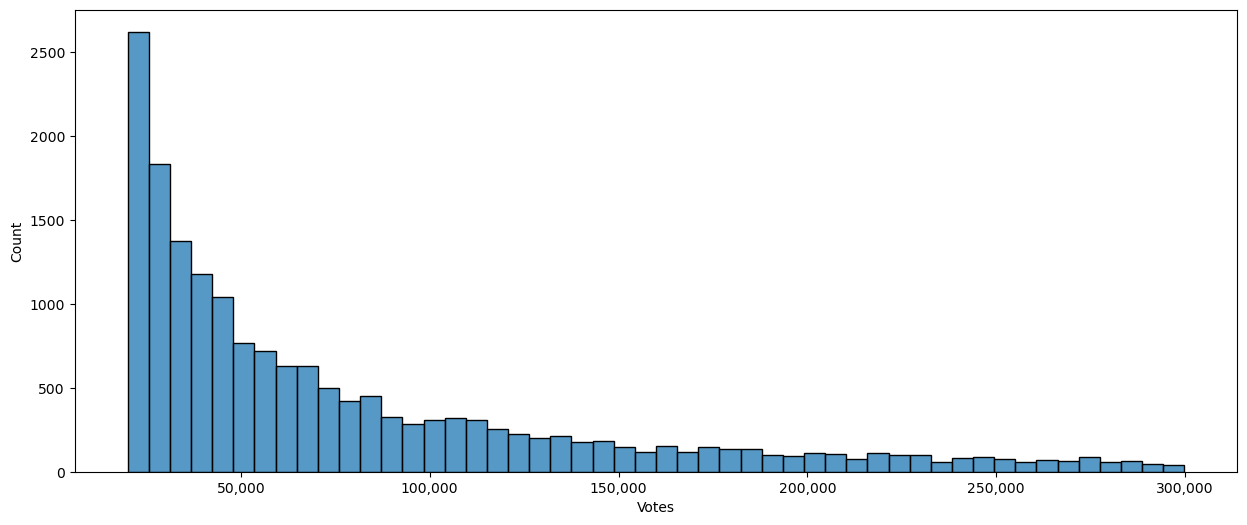

In [16]:
plt.figure(figsize=(15,6))
sns.histplot(data[data['Votes'] < 300000]['Votes'], bins=50, kde=False)
ax = plt.gca()

# Format with commas (e.g., 1,000,000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

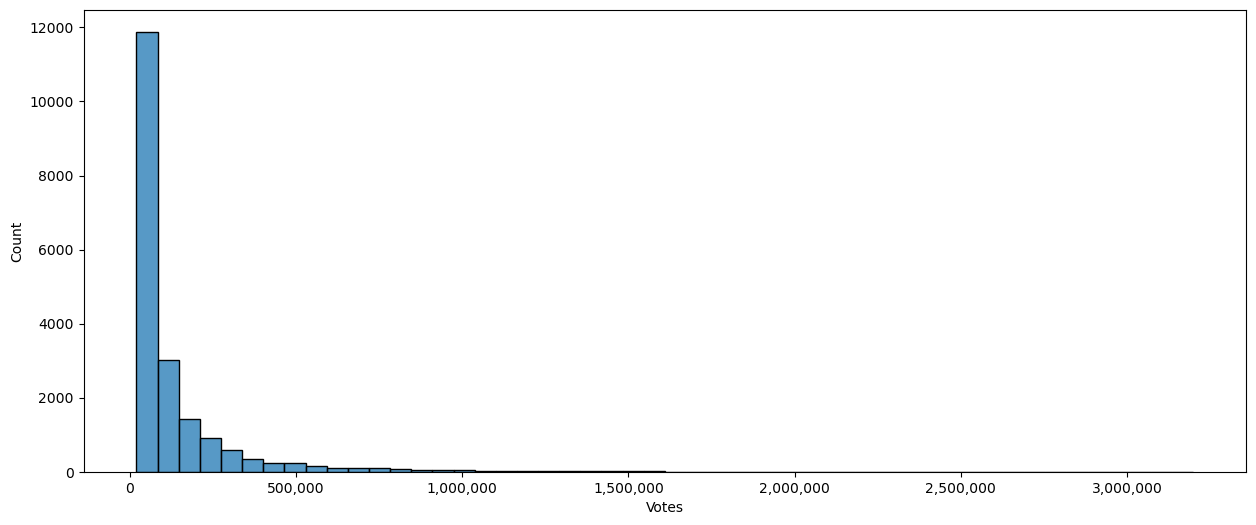

In [15]:
plt.figure(figsize=(15,6))
sns.histplot(data['Votes'], bins=50, kde=False)
ax = plt.gca()

# Format with commas (e.g., 1,000,000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [23]:
C = data['Rating'].mean()

m = data['Votes'].quantile(0.90)

data['score'] = (
    (data['Rating'] * data['Votes'] + m * C)
    / (data['Votes'] + m)
).round(2)

In [24]:
data

,Title,Year,Genres,Rating,Votes,score
0,The Shawshank Redemption,1994,Drama,9.3,3199370,9.07
1,The Godfather,1972,Crime,9.2,2232183,8.90
1,The Godfather,1972,Drama,9.2,2232183,8.90
2,The Chaos Class,1975,Comedy,9.1,46358,6.97
3,The Dark Knight,2008,Crime,9.1,3180142,8.89
...,...,...,...,...,...,...
7418,Sadak 2,2020,Action,1.2,97207,5.32
7418,Sadak 2,2020,Drama,1.2,97207,5.32
7419,Reis,2017,Biography,1.0,74715,5.53
7419,Reis,2017,Drama,1.0,74715,5.53


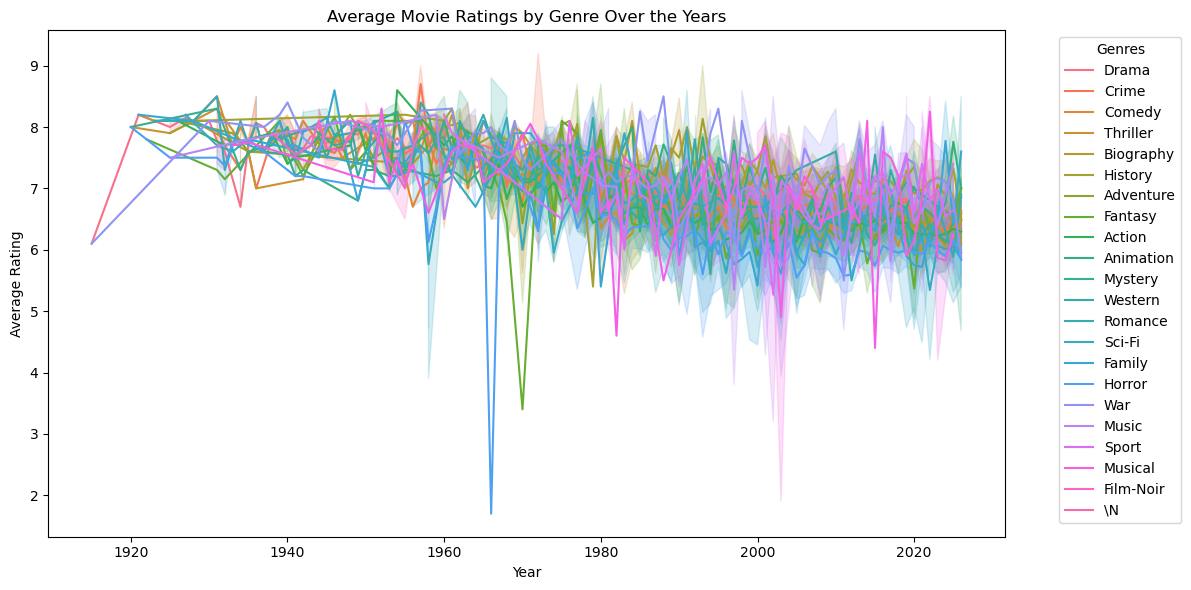

In [5]:
#line chart for generes over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='Year', y='Rating', hue='Genres', marker=None)
plt.title('Average Movie Ratings by Genre Over the Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
data

,Title,Year,Genres,Rating,Votes
0,The Shawshank Redemption,1994,Drama,9.3,3199370
1,The Godfather,1972,Crime,9.2,2232183
1,The Godfather,1972,Drama,9.2,2232183
2,The Chaos Class,1975,Comedy,9.1,46358
3,The Dark Knight,2008,Crime,9.1,3180142
...,...,...,...,...,...
7418,Sadak 2,2020,Action,1.2,97207
7418,Sadak 2,2020,Drama,1.2,97207
7419,Reis,2017,Biography,1.0,74715
7419,Reis,2017,Drama,1.0,74715


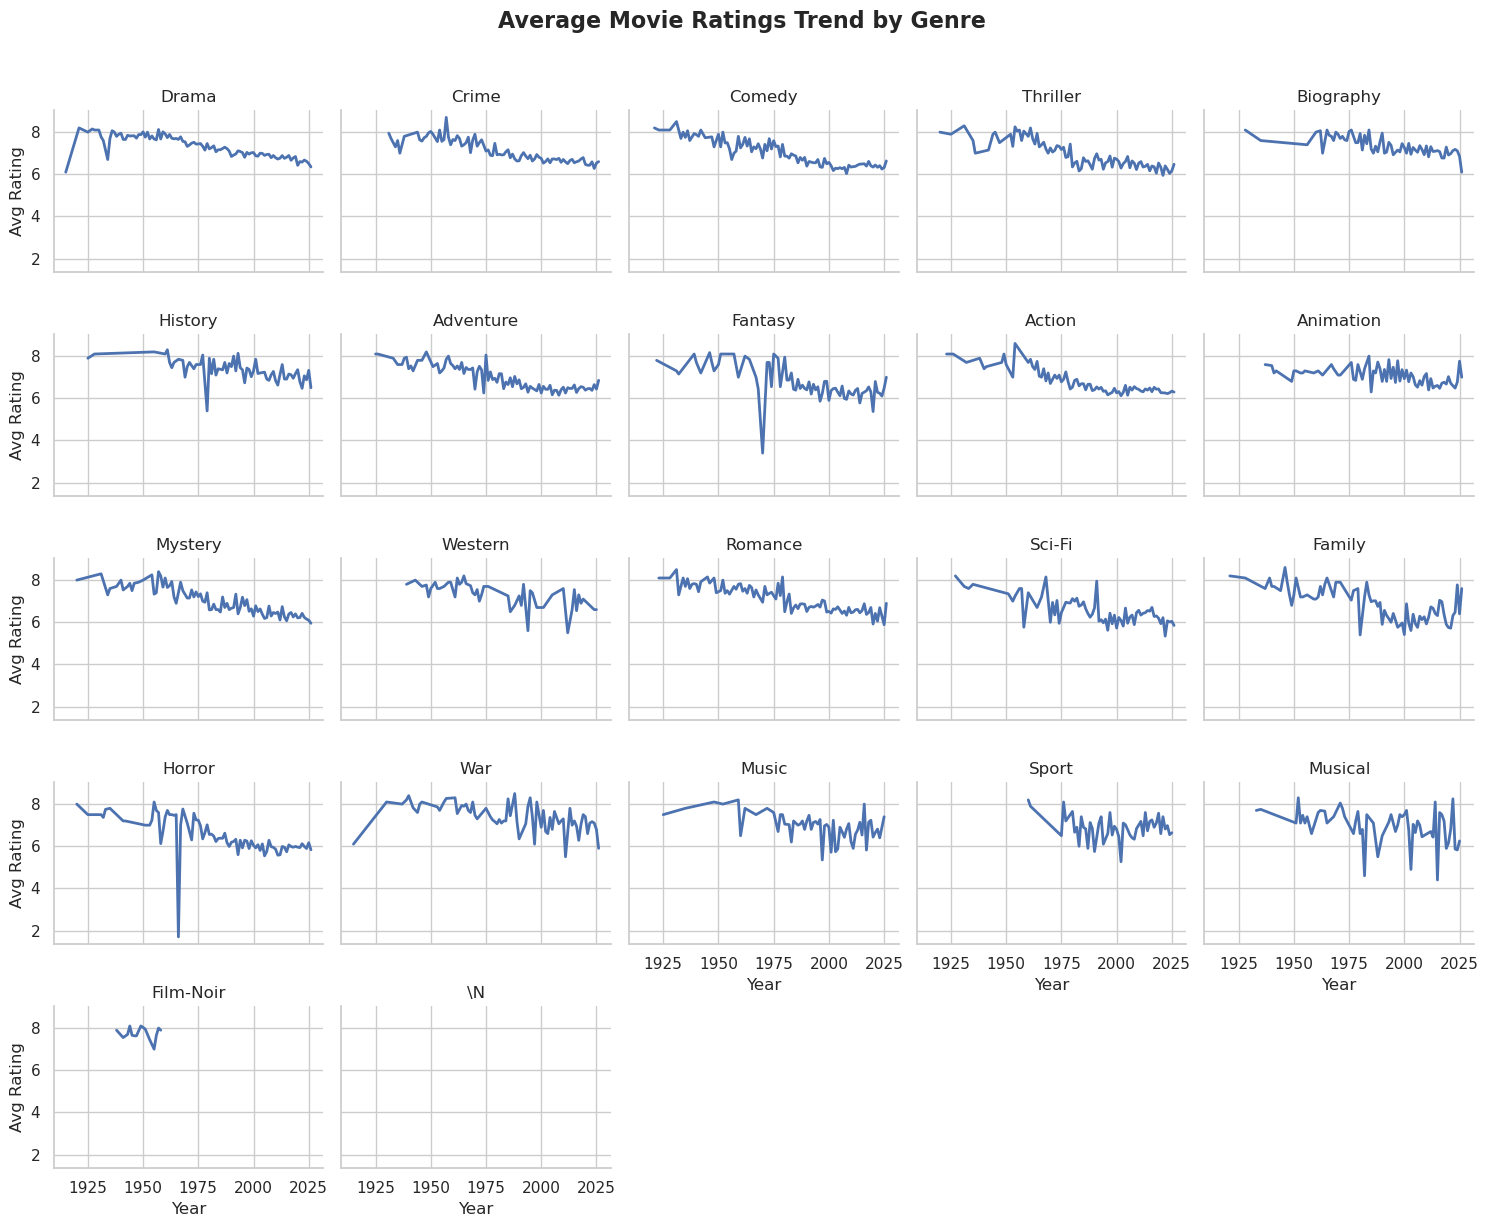

In [10]:
sns.set_theme(style="whitegrid")

# 3. Create a faceted line plot (Small Multiples)
g = sns.relplot(
    data=data,
    x="Year",
    y="Rating",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()

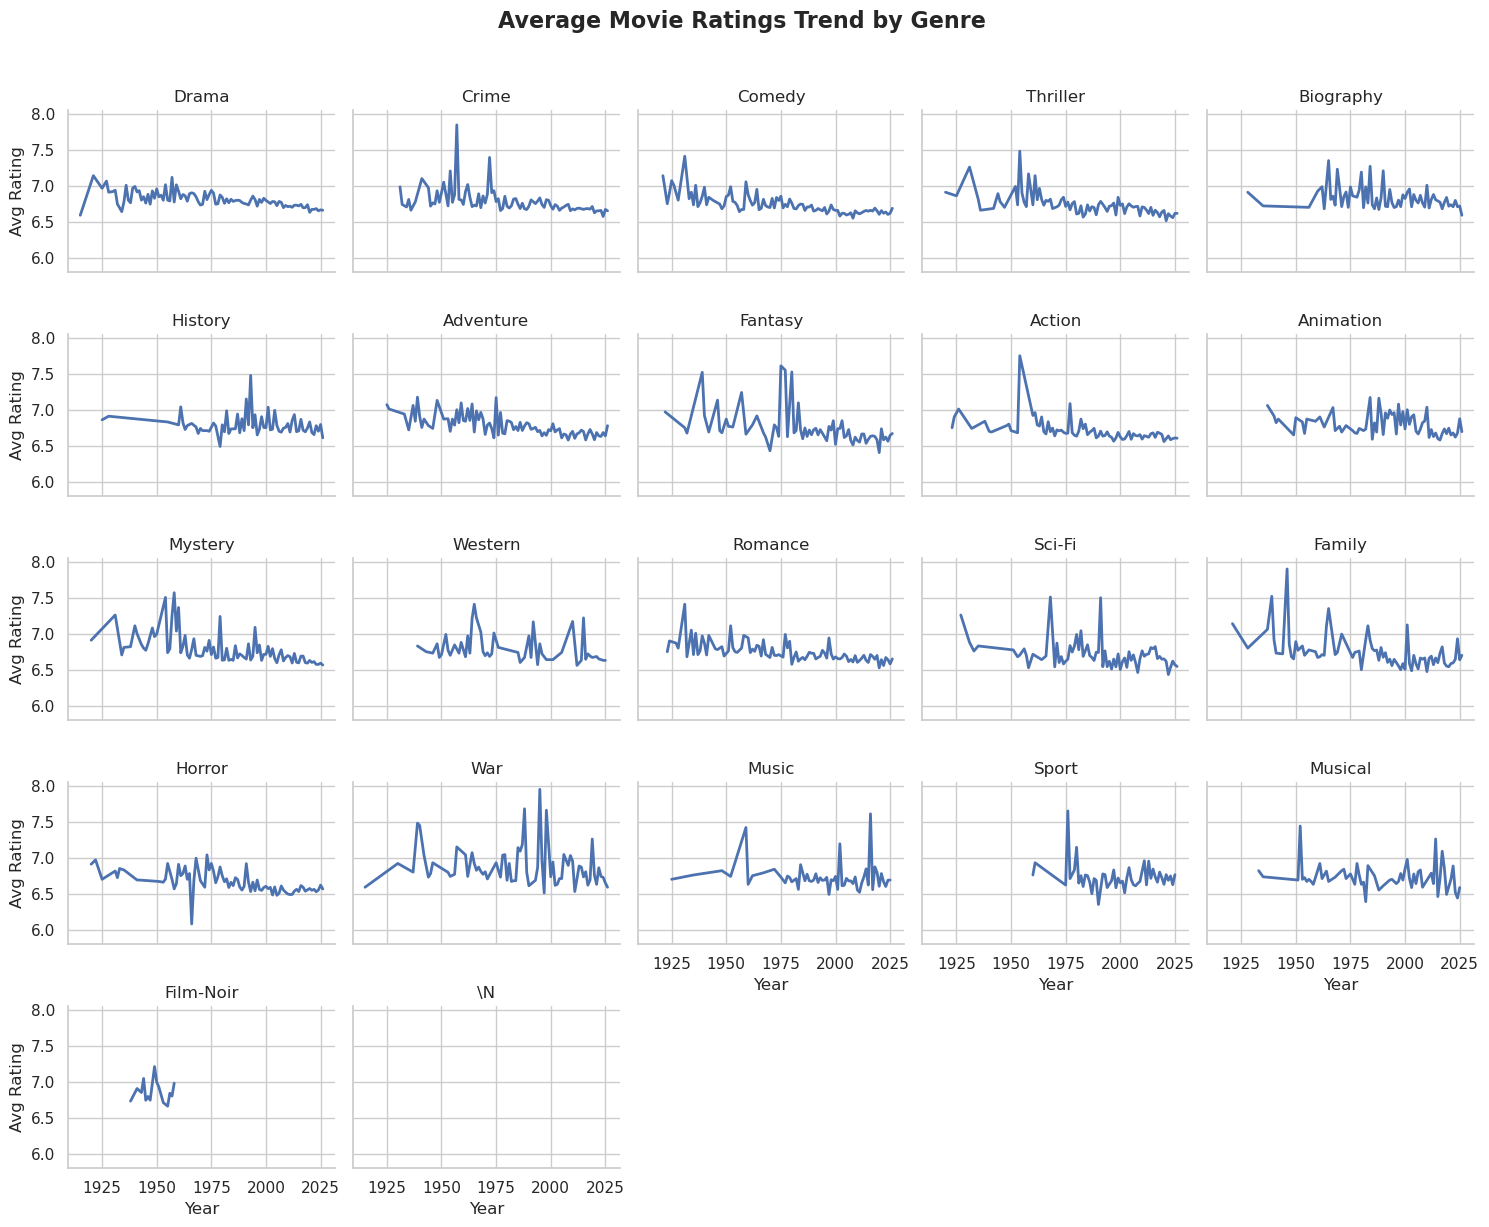

In [27]:
sns.set_theme(style="whitegrid")

# 3. Create a faceted line plot (Small Multiples)
g = sns.relplot(
    data=data,
    x="Year",
    y="score",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()

In [35]:
data = data.sort_values(['Genres', 'Year'])
data['smoothed_score'] = data.groupby('Genres')['score'].transform(lambda x: x.rolling(window=5, min_periods=1).mean()).round(2)

In [36]:
data

,Title,Year,Genres,Rating,Votes,score,smoothed_score
238,Safety Last!,1923,Action,8.1,24903,6.76,6.76
239,Sherlock Jr.,1924,Action,8.1,66093,6.91,6.84
241,The General,1926,Action,8.1,105226,7.02,6.90
854,Scarface,1932,Action,7.7,33481,6.75,6.86
524,The Adventures of Robin Hood,1938,Action,7.9,57783,6.85,6.86
...,...,...,...,...,...,...,...
3473,The Power of the Dog,2021,Western,6.8,237810,6.71,6.72
4145,The Harder They Fall,2021,Western,6.6,77915,6.64,6.69
3485,Redeeming Love,2022,Western,6.8,20603,6.66,6.68
4190,Horizon: An American Saga - Chapter 1,2024,Western,6.6,45532,6.64,6.68


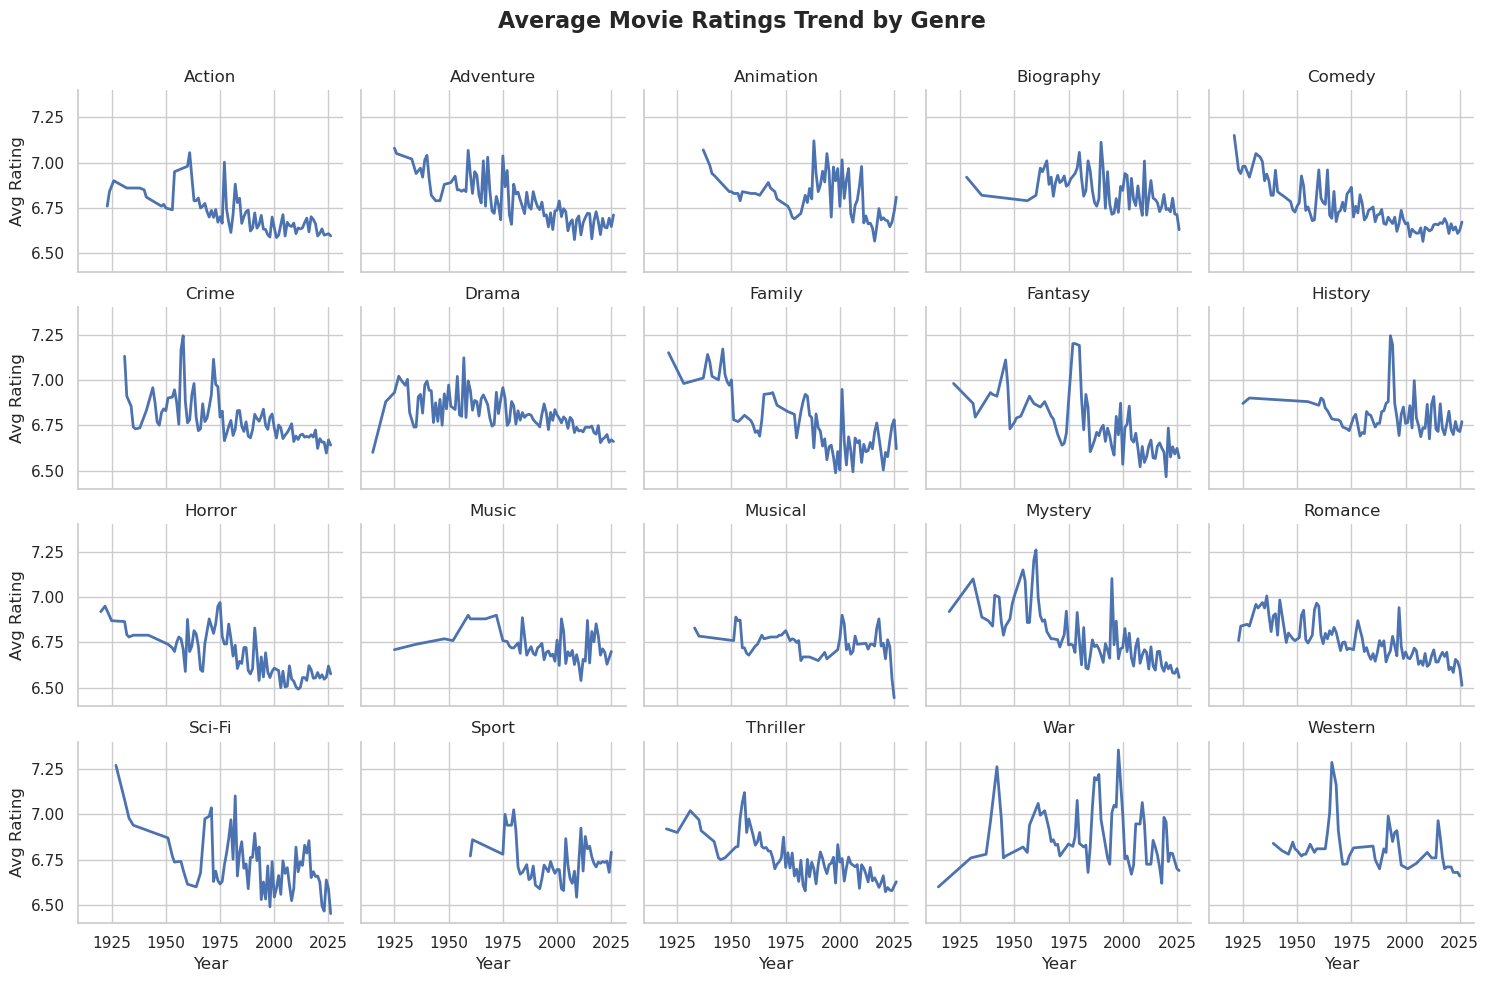

In [41]:
g = sns.relplot(
    data=data,
    x="Year",
    y="smoothed_score",
    col="Genres",  # This splits the data into subplots by genre
    col_wrap=5,  # Sets 5 subplots per row
    kind="line",
    errorbar=None,  # Removes the overlapping shaded areas for a cleaner look
    height=2.5,  # Height of each individual subplot
    aspect=1.2,  # Aspect ratio of each subplot
    linewidth=2,
)

g.set_titles("{col_name}")  # Clean subplot titles (just the Genre name)
g.set_axis_labels("Year", "Avg Rating")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Average Movie Ratings Trend by Genre", fontsize=16, weight="bold")

plt.show()